<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Kala Ariadna Guevara


# Introducción

En el presente trabajo práctico se estudia el proceso de cuantización, el cual forma parte fundamental del funcionamiento de un conversor analógico-digital (ADC). La cuantización consiste en transformar una señal continua en amplitud en una señal discreta, asignando a cada valor de entrada el nivel más cercano dentro de un conjunto finito de valores posibles.

Este proceso introduce inevitablemente un error, conocido como error de cuantización, definido como la diferencia entre la señal de entrada al cuantizador y la señal cuantizada. Dicho error se encuentra acotado dentro del intervalo [−q/2,q/2], donde q es el paso de cuantización, es decir, la distancia entre dos niveles consecutivos del cuantizador. El paso de cuantización depende del rango dinámico del ADC y de la cantidad de bits utilizados. Para un ADC de B bits con un rango de entrada de ±Vcc, el paso de cuantización está dado por:
$$
q = \frac{2V_{cc}}{2^B}
$$
A partir de este parámetro, es posible modelar el error de cuantización como una variable aleatoria. Bajo ciertas condiciones ideales, se asume que este error se distribuye uniformemente en el intervalo mencionado, lo que permite simplificar su análisis. En este caso, la distribución uniforme se utiliza como modelo teórico porque representa la situación en la cual el error no presenta sesgos ni correlación con la señal de entrada, distribuyéndose de manera equiprobable entre sus valores posibles. Esta hipótesis resulta especialmente útil, ya que permite modelar el error de cuantización como un ruido aleatorio distribuido uniformemente en el intervalo [−q/2,q/2]. A partir de esta distribución, se puede calcular su potencia media como:
$$
P_q = \frac{q^2}{12}
$$
Este modelo simplifica el análisis, ya que permite tratar al error de cuantización como una fuente de ruido que se suma a la señal. De esta manera, es posible estudiar su efecto tanto en el dominio temporal como en el dominio frecuencial, por ejemplo a través de la densidad espectral de potencia.

En este trabajo se implementa una simulación de un ADC, incorporando tanto el efecto del ruido analógico como el de la cuantización, con el objetivo de analizar su impacto sobre una señal senoidal mediante herramientas como el histograma del error y la densidad espectral de potencia.

#### **Esquema 1**

<img src="./esquemadigi.jpg" width="400" /> 

# Desarrollo
El desarrollo del código se realizó a partir de la consigna, comenzando por la definición de los parámetros principales del sistema (cantidad de bits, rango del ADC, frecuencia de muestreo, etc.) y la implementación directa de las expresiones teóricas dadas.

Durante la implementación surgió la duda de cuándo utilizar la señal con ruido y cuándo sin ruido. Para resolver esto de forma práctica, se decidió encapsular los cálculos dentro de una función que modela el ADC, incorporando como argumento un parámetro booleano que permite seleccionar si la señal de entrada se considera con ruido o sin ruido. De esta manera, el código resulta más flexible y evita duplicación de cálculos. La función generadora de la señal senoidal fue reutilizada de trabajos prácticos anteriores.

En la primera parte, se grafican la señal senoidal original, la señal contaminada con ruido y la señal cuantizada. Para que el gráfico sea comparable con el presentado en la consigna, fue necesario ajustar la visualización temporal de modo de observar un único período de la señal. Esto se logró seleccionando adecuadamente la frecuencia y/o recortando el intervalo de tiempo graficado.

En la segunda parte, se construyó el histograma del error de cuantización, definido como la diferencia entre la señal de entrada al cuantizador y la señal cuantizada. Se tuvo en cuenta que, para observar la distribución uniforme teórica del error, no es conveniente utilizar directamente una señal senoidal pura, ya que esta no recorre uniformemente todos los niveles de cuantización. Por ello, se consideró una señal adecuada que permita verificar este comportamiento.

Finalmente, la tercera parte consistió en el análisis de la densidad espectral de potencia. Esta etapa resultó más compleja, ya que requiere un orden cuidadoso en la aplicación de las operaciones. Primero se calcularon las transformadas de Fourier de las distintas señales, luego se obtuvieron los vectores de frecuencia y se seleccionó únicamente la parte positiva del espectro. A continuación, se calculó la densidad espectral de potencia y se expresó en escala logarítmica (dB). Por último, se graficaron los resultados junto con los niveles de piso de ruido analógico y de cuantización. Es importante destacar que, al tratarse de potencia, la conversión a decibeles se realiza utilizando 10 log 10(⋅) y no 20 log 10(⋅).

# Codigo y gráficos

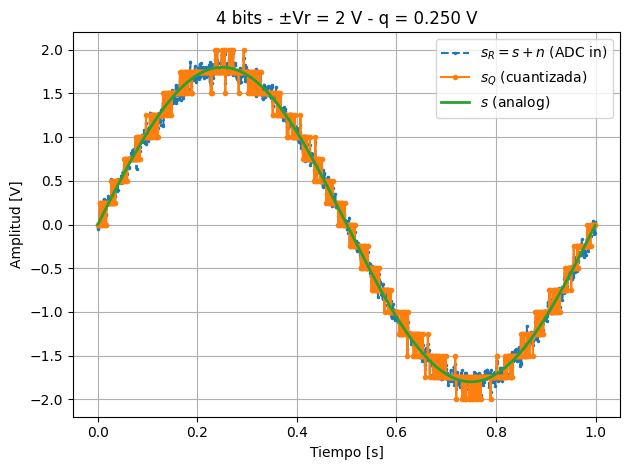

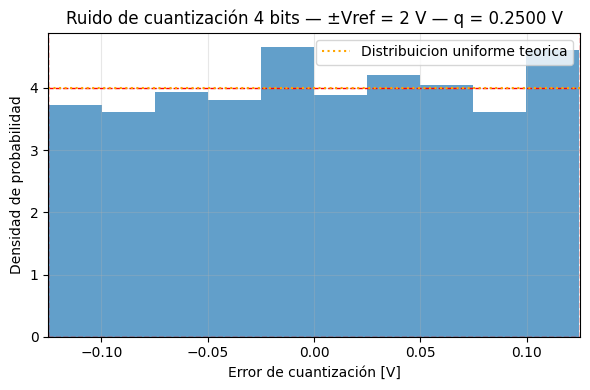

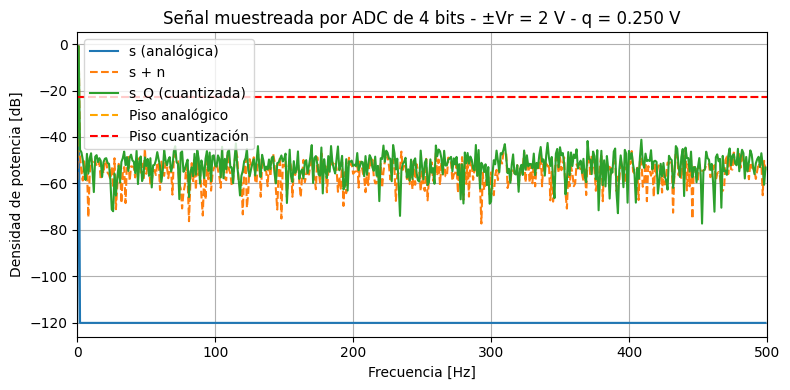

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Wed Apr  8 17:10:27 2026

@author: gueva
"""
import numpy as np
import matplotlib.pyplot as plt

#%%
#definimos valores
B = 4 #bits
Vcc = 2 #volts
kn = 1 #para escalar Pq
fs = 1000
N = 1000
frec = 50

#%%
#funciones
def funcion_seno(amp, desplazo, frec, fase, cant_muestras, frec_muestreo):
    tt = np.arange(cant_muestras) / frec_muestreo
    xx = amp * np.sin(2 * np.pi * frec * tt + fase) + desplazo
    return tt.reshape(-1,1), xx.reshape(-1,1)

#cuantizacion
def simular_adc(s, B, Vcc, kn, N, usar_ruido=True):
    # cuantización
    q = Vcc / (2**(B-1))
    Pq = (q**2) / 12

    # potencia de ruido
    Pn = kn * Pq
    mu = 0

    # ruido gaussiano
    n = np.random.normal(mu, np.sqrt(Pn), N).reshape(-1,1)

    # señal contaminada
    sr = s + n

    # selector de entrada al ADC
    if usar_ruido:
        s_in = sr
    else:
        s_in = s

    # cuantización
    sq = np.round(s_in / q) * q

    # error
    ee = sq - s_in

    return sr, sq, ee, q, Pq, Pn

#%%
#llamamos a las funciones
tt, s = funcion_seno(amp=1.8, desplazo=0, frec=fs/N, fase=0, cant_muestras=N, frec_muestreo=fs)
#uso esta frec para que me muestre un periodo
sr, sq, ee, q, Pq, Pn = simular_adc(s, B, Vcc, kn, N)
#%%
#PARTE 1
#le pedi al chat que me lo ponga al grafico fancy
plt.figure()
plt.plot(tt, sr, label=r'$s_R = s + n$ (ADC in)', linestyle='--', marker='.', markersize=3)
plt.plot(tt, sq, label=r'$s_Q$ (cuantizada)', linestyle='-', marker='o', markersize=3)
plt.plot(tt, s, label=r'$s$ (analog)', linewidth=2)
plt.title(f'{B} bits - ±Vr = {Vcc} V - q = {q:.3f} V')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

#%%
#lo rellamo cambiando la frecuencia
#%%
#PARTE 2

#por si se necesita una menor frecuencia
#tt, s = funcion_seno(amp=1.8, desplazo=0, frec=50, fase=0, cant_muestras=N, frec_muestreo=fs)
#sr, sq, ee, q, Pq, Pn = simular_adc(s, B, Vcc, kn, N)
#sq_hist = np.round(s / q) * q
#ee_hist = sq_hist - s

sq_hist = np.round(sr / q) * q
ee_hist = sq_hist - sr

#graficos
fig2, ax4 = plt.subplots(figsize=(6, 4))

#histograma
n_bins = 10
ax4.hist(ee_hist, bins=n_bins, density=True, alpha=0.7)
ax4.axvline(q/2, color='red', linestyle='--', linewidth=1)
ax4.axvline(-q/2, color='red', linestyle='--', linewidth=1)
#rectangulo lindo
ax4.hlines(1/q, -q/2, q/2, colors='red', linestyles='--', linewidth=1)
ax4.hlines(0, -q/2, q/2, colors='red', linestyles='--', linewidth=1)
#densidad teorica
ax4.axhline(1/q, color='orange', linestyle=':', label='Distribuicion uniforme teorica')
# labels
ax4.set_xlabel('Error de cuantización [V]')
ax4.set_ylabel('Densidad de probabilidad')
ax4.set_title(f'Ruido de cuantización {B} bits — ±Vref = {Vcc} V — q = {q:.4f} V')
ax4.set_xlim(-q/2, q/2)
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#%%
#PARTE 3
#fft
S  = np.fft.fft(s.flatten())
SR = np.fft.fft(sr.flatten())
SQ = np.fft.fft(sq.flatten())

#frec
f = np.fft.fftfreq(N, 1/fs)

# solo frecuencias positivas
idx = f >= 0

#densidad de potencia
PSD_s  = (np.abs(S)**2)  / (N * fs)
PSD_sr = (np.abs(SR)**2) / (N * fs)
PSD_sq = (np.abs(SQ)**2) / (N * fs)

#lo quiero en db
PSD_s_db  = 10 * np.log10(PSD_s  + 1e-12)
PSD_sr_db = 10 * np.log10(PSD_sr + 1e-12)
PSD_sq_db = 10 * np.log10(PSD_sq + 1e-12)

#le pido a chat que me grafique lindo
plt.figure(figsize=(8,4))

plt.plot(f[idx], PSD_s_db[idx], label='s (analógica)')
plt.plot(f[idx], PSD_sr_db[idx], '--', label='s + n')
plt.plot(f[idx], PSD_sq_db[idx], label='s_Q (cuantizada)')

# pisos
piso_analogico = 10*np.log10(Pn)
piso_digital = 10*np.log10(Pq)
plt.axhline(piso_analogico, linestyle='--', color='orange', label='Piso analógico')
plt.axhline(piso_digital, linestyle='--', color='red', label='Piso cuantización')

plt.title(f'Señal muestreada por ADC de {B} bits - ±Vr = {Vcc} V - q = {q:.3f} V')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.xlim(0, fs/2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis gráficos
Por otro lado, surgieron algunas dificultades durante el desarrollo. En particular, el histograma del error de cuantización generó dudas, ya que su distribución no resultó perfectamente uniforme, a diferencia de lo esperado teóricamente. Esto llevó a analizar en mayor profundidad las condiciones bajo las cuales se cumple el modelo ideal, comprendiendo que depende de las características de la señal de entrada y del ruido presente. En este caso, el cálculo del error se realizó utilizando la señal de entrada al ADC contaminada con ruido, por lo que el error obtenido no corresponde únicamente al error de cuantización, sino que también incluye el efecto del ruido analógico, lo cual altera su distribución y la desvía del comportamiento uniforme ideal.

Por otro lado, en el análisis de la densidad espectral de potencia, se observa que los niveles correspondientes al piso de ruido analógico y de cuantización aparecen por encima del espectro de las señales. Esto puede parecer contradictorio en una primera observación, pero se explica por la diferencia entre potencia total y densidad espectral de potencia. Mientras que los valores Pn y Pq, representan potencia total, la PSD distribuye dicha potencia a lo largo del ancho de banda, resultando en niveles menores en cada frecuencia. En consecuencia, no se está perdiendo la señal, sino que la energía del ruido se encuentra distribuida en frecuencia, mientras que la señal senoidal concentra su energía en una frecuencia específica, generando un pico claramente identificable en el espectro.

# Conclusión
En este trabajo se logró aplicar y comprender el proceso de cuantización mediante su implementación en código, respetando el orden adecuado de los cálculos y analizando el rol de cada etapa dentro del modelo de un ADC. A través de los distintos gráficos obtenidos, fue posible visualizar qué sucede cuando una señal atraviesa el conversor, tanto a la entrada como a la salida, lo que permitió interpretar de manera más concreta el efecto de la cuantización.

Finalmente, se utilizó la herramienta ChatGPT como apoyo para corregir partes del código y mejorar la redacción del informe, facilitando la comprensión de algunos conceptos y la organización del trabajo.

# Biblografía
1. Holton, T. (2021). Digital signal processing: Principles and applications. Cambridge University Press. https://doi.org/10.1017/9781108290050
2. NumPy user guide — NumPy v2.3 Manual. (2025). Numpy.org. https://numpy.org/doc/stable/user/index.html
3. Signal processing (scipy.signal) — SciPy v1.16.1 Manual. (2025). Scipy.org. https://docs.scipy.org/doc/scipy/reference/signal.html#waveforms
